# HW 5

## 2.1


### 3.

Constant heat flow $\Phi$ at $z=0$ and constant temp $T_0$ at $z=L$. No limits on $x,y$ so we can drop them. This is type II mixed BC 

$$
    \dot u = K \nabla^2 u
\\  \dot u = K u''(z) = 0
\\  u(z) = A + Bz
\\  u'(z) = \Phi = B
\\  T_0 = A + BL \rightarrow  A = T_0 - \Phi L
\\  u(z) = T_0 - \Phi L + \Phi z
$$

### 7.

Constant temp $T_1$ at $z=0$ and $T_2$ at $z=L$. 

$$
    \dot u = K \nabla^2 u + r = 0
\\  \nabla^2 u(z) = Z''(z) = -\frac{r}{K}
\\  u(z) = A + Bz - \frac{r}{K}z^2
\\  u(0) = A = T_1
\\  u(L) = T_1 + BL - \frac{r}{K}L^2 = T_2
\\  \rightarrow B = \frac{T_2-T_1 + \frac{rL^2}{K}}{L}
\\[0.25em]  
    \rightarrow B = \frac{T_2-T_1}{L} + \frac{rL}{K}
\\[0.25em]  
    u(z) = T_1 + \left(\frac{T_2-T_1}{L} + \frac{rL}{K}\right)z - \frac{r}{K}z^2
$$
Setting $T_1 = T_2 = T$ we have

$$
\\  u  (z) = T + \left(\frac{rL}{K}\right)z - \frac{r}{K}\left( z\right)^2
\\[0.25em]  u_z(z) = \frac{rL}{K} - \frac{2r}{K} z
\\[0.25em]  u_z(L/2) = \frac{rL}{K} - \frac{rL}{K} = 0

$$

## 2.2

### 1. 

The general formula is 

$$
    u(t,x) = \sum_{n=0}^\infty c_n e^{- K \lambda_n t} w_n(x)
$$
Where we have Dirichlet boundary conditions
$$
    w_n = \sin\left( n \pi z \over L\right)
\\  \lambda_n = \left(n \pi \over L \right)^2
\\  c_n 
    = \frac{2}{L}\int_0^L z \sin\left( n \pi z \over L\right) dz
\\  =\frac{2}{L}\frac{\sin(n \pi)-n\pi \cos(n\pi)}{\left(n\pi \over L\right)^2}
\\  =-\frac{2L}{n\pi }(-1)^n
    = \frac{2L}{n\pi }(-1)^{n+1}
\\  u(t,z) = 2 + \frac{2L}{\pi } \sum_{n=1}^\infty \frac{(-1)^{n+1}}{n} e^{- K \left(n \pi \over L \right) t} \sin\left( n \pi z \over L\right)
$$

### 3.

Mixed conditions $u(t,0) = 0, u_z(t,L)=0$ with initial condition $u(0,z)=3 \sin \left(\pi z \over 2 L\right)  + 5 \sin \left( 3 \pi z \over 2 L\right)$

$$
    \lambda_n = \left( (2n-1)\pi \over 2L\right)^2
\\  w_n(z) = \sin\left({
    (2n-1) \pi  \over 2L}z
    \right)
\\  u(t,z) = \sum_{n=0}^\infty c_n e^{-K\lambda_n t}w_n(z)
$$
Aparently the solution to this problem should drop the summation. Note that our expression should collapse into the initial conditions for $t=0$

$$
      u(0,z) 
    = \sum_{n=0}^\infty c_n w_n(z) 
    = 3 \sin \left(\pi z \over 2 L\right)  
    + 5 \sin \left( 3 \pi z \over 2 L\right)
$$
$w_n$ clearly only matches for $n=1$ and $n=2$
$$
    w_1(z) = \sin\left(\pi z \over 2L\right) \rightarrow c_1 = 3
\\  w_2(z) = \sin\left(3\pi z \over 2L\right) \rightarrow c_2 = 5
$$
with all other $c_n=0$. Thus, our final result is
$$  
      u(t,z) 
    = 3 e^{-K \left( \pi \over 2L\right)^2 t} \sin\left(\pi z \over 2L\right)
    + 5 e^{-K \left(3\pi \over 2L\right)^2 t} \sin \left( 3 \pi z \over 2 L\right)

$$

Here's a plot of this solution, where the inital condition is shown at the top and time propogates downwards, although the color version is a bit prettier

<!-- $$
c_n = {2 \over L} \int_0^L \left(
      3 \sin \left(\pi z \over 2 L\right) 
    + 5 \sin \left( 3 \pi z \over 2 L\right)
    \right)\sin\left({
    (2n-1) \pi  \over 2L}z
    \right) dz
\\  = {6 \over L} \int_0^L 
      \sin \left(\pi z \over 2 L\right) 
      \sin  \left({
            (2n-1) \pi  \over 2L}z
            \right) dz

    + {10 \over L} \int_0^L \left(
      \sin \left( 3 \pi z \over 2 L\right)\right)
      \sin  \left({
            (2n-1) \pi  \over 2L}z
            \right) dz

$$ -->


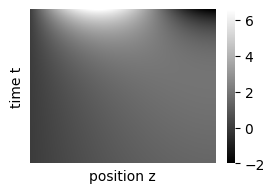

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from numpy import sin, exp, pi

L = 1
K = 1

z = np.linspace(0,  L, 1000)
t = np.linspace(0, 0.3, 1000)

Z, T = np.meshgrid(z,t)

soln = ( 
     3*exp(-K*(  pi/2/L)**2*T)*sin(  pi*Z/2/L)
    +5*exp(-K*(3*pi/2/L)**2*T)*sin(3*pi*z/2/L)
)

plt.figure(figsize=(3,2)) # saves ink
sns.heatmap(soln, cmap='grey', xticklabels=False, yticklabels=False)
plt.xlabel('position z')
plt.ylabel('time t');


## 2.3

### 1 

<!-- With no $r$ term this should be easy -->

Can we use our formula from 11/4? It is in terms of $u(L,t) = \beta(t)$, not $u_z(L,t)$. What about 10/28? Not sure how to work in $h$. Let's read the textbook.

__2.3.1 statement of problem:__
$$
    u(0,t) = T_1 \rightarrow \alpha= 0
\\  u(L,t) = \Phi_2 \rightarrow \beta = \pi/2,\ \Phi' = \Phi_2/L
\\  u(z,0) = T_3 \rightarrow f(z)=T_3
\\  r = 0
$$

<!-- $$

u_{in}(x,t) = \sum_{n=1}^\infty \left[u_n(t) \sin\left(\pi n x \over a \right)\right]
$$ -->



<!-- Actually, we can find $\beta(t)$. 

$$
    u_z(L,t) = \Phi
$$ -->



<!-- Let's follow the formula from class. The time-dependent version is a bit overkill since we're dealing with constants, but here it is:

$$
\begin{matrix}
u(0,t) = \alpha(t) = T_1 & u(L,t) = \beta(t)
\end{matrix}
$$ -->



With no $r$ this should be easy. Start with steady-state solution

$$
    U_t = K U_{zz} = 0
\\  U (z) = A + Bz
\\  U (0) = A = T_1 
\\  U'(L) = B = \Phi_2
\\  U(z) = T_1 + \Phi_2 z
$$
Subtract this from the solution to create $v(z,t)$ with homogeneous boundaries
$$
    v(z,t) = u(z,t) - U(z)
\\  v  (0,t) = 0
\\  v_t(L,t) = 0
$$
Mixed boundary conditions
$$
    v(z,t) = \sum_{n=0}^\infty c_n e^{-K\lambda_n t} w_n(z)
\\  \lambda_n =\left((2n-1)\pi \over 2L \right)^2
\\  w_n(z) = \sin\left({(2n-1)\pi \over 2L}z \right)
$$

The initial condition $T_3$ has $U$ subtracted out now

$$
    c_0 = {2 \over L}\int_0^L \left(T_3 - T_1 - \Phi_2 z \right)dz
\\  c_n = {2 \over L}\int_0^L \left(T_3 - T_1 - \Phi_2 z \right)\sin\left({(2n-1)\pi \over 2L}z \right)dz
$$

In [ ]:
from sympy import symbols, sin, integrate, simplify, pi

z, L, T_1, Phi_2, T_3 = symbols('z L T_1 Phi_2 T_3')
n = symbols('n', integer=True)
U_z = T_1 + Phi_2*z
c_0 = 2/L*integrate(T_3-U_z, (z,0,L))
display(simplify(c_0))

c_n = 2/L*integrate((T_3-U_z)*sin((2*n-1)*pi/2/L*z), (z,0,L))
display(simplify(c_n))

-L*Phi_2 - 2*T_1 + 2*T_3

-4*(-2*(-1)**n*L*Phi_2 + 2*pi*T_1*n - pi*T_1 - 2*pi*T_3*n + pi*T_3)/(pi**2*(2*n - 1)**2)

Now, just add back in $U(z)$ to get $u(t,z)$

$$
u(t,z) = v(t,z) + U(z)
\\  = \sum_{n=0}^\infty c_n e^{-K \left((2n-1)\pi \over 2L \right)^2 t} \sin\left({(2n-1)\pi \over 2L}z \right) + T_1 + \Phi_2z
$$



### 5

### 7

## 2.5

### 5

### 9

### 13